# Aula: Visualização de Dados e Gráficos Principais

Neste notebook, vamos aprender como importar conjuntos de dados de diferentes fontes e utilizar as bibliotecas **matplotlib** e **seaborn** para criar visualizações informativas e extrair estatísticas essenciais.

In [ ]:
# Importação das bibliotecas fundamentais
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual padrão para os gráficos
sns.set_theme(style="whitegrid")

## 1. Importando Dados

Podemos importar dados (como arquivos .csv) de diversas maneiras. As mais comuns no Google Colab são através do Google Drive ou diretamente de um link (URL).

In [ ]:
# Método A: Importando do Google Drive
from google.colab import drive

# 1. Conecta o Colab ao seu Google Drive
drive.mount('/content/drive/')

# 2. Carrega o arquivo (ajuste o caminho de acordo com o seu Drive)
caminho_drive = '/content/drive/My Drive/Disciplinas/CienciaDados/tips.csv'
df_drive = pd.read_csv(caminho_drive)
df_drive.head()

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# Método B: Importando diretamente de um Link (URL)
# Utilizaremos um dataset público clássico de gorjetas (tips) para os exemplos
url_dataset = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'
df = pd.read_csv(url_dataset)

# Exibindo as 5 primeiras linhas para conferência
display(df.head())

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


##2. Principais Formas de Visualização e Estatísticas
A escolha do gráfico correto depende do que queremos descobrir sobre os dados: distribuição, correlação, tendências ou comparação entre categorias.

###2.1 Histograma (Distribuição de Frequência)
Mostra como os dados numéricos estão distribuídos. Ideal para ver a concentração dos dados e a assimetria.

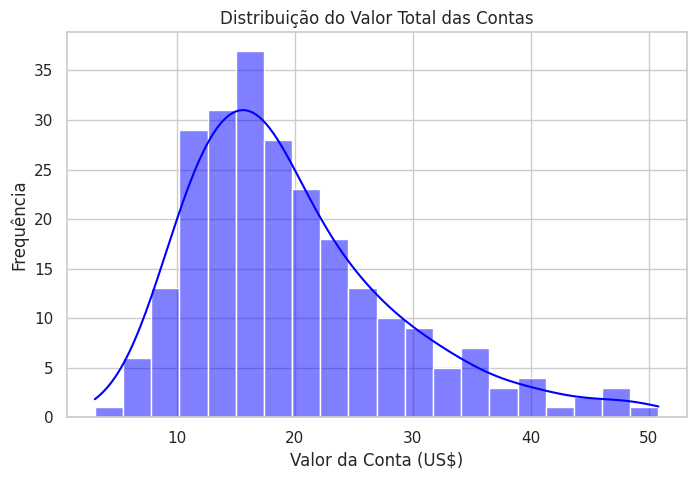

Média da conta: $ 19.79
Mediana da conta: $ 17.8


In [ ]:
plt.figure(figsize=(8, 5))
# kde=True adiciona a linha de densidade probabilística
sns.histplot(data=df, x="total_bill", bins=20, kde=True, color="blue")
plt.title("Distribuição do Valor Total das Contas")
plt.xlabel("Valor da Conta (US$)")
plt.ylabel("Frequência")
plt.show()

# Estatísticas relacionadas
print("Média da conta: $", round(df['total_bill'].mean(), 2))
print("Mediana da conta: $", round(df['total_bill'].median(), 2))

###2.2 Boxplot (Gráfico de Caixa)
Excelente para resumir cinco estatísticas principais: valor mínimo, 1º quartil, mediana (2º quartil), 3º quartil e valor máximo. Também evidencia os outliers (pontos atípicos).

/tmp/ipykernel_2434/1436911995.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="day", y="total_bill", palette="Set2")


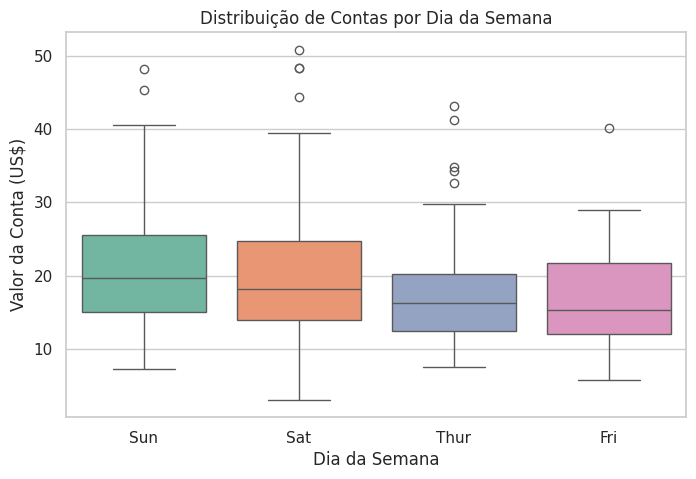

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="day", y="total_bill", palette="Set2")
plt.title("Distribuição de Contas por Dia da Semana")
plt.xlabel("Dia da Semana")
plt.ylabel("Valor da Conta (US$)")
plt.show()

###2.3 Gráfico de Dispersão (Scatter Plot)
Utilizado para verificar a correlação entre duas variáveis numéricas. Nos ajuda a responder: "Quando uma variável aumenta, a outra também aumenta?".

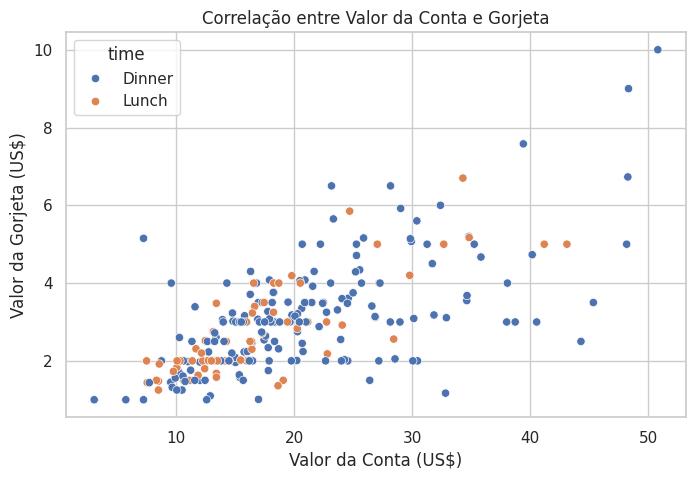

Coeficiente de correlação: 0.68


In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="total_bill", y="tip", hue="time", palette="deep")
plt.title("Correlação entre Valor da Conta e Gorjeta")
plt.xlabel("Valor da Conta (US$)")
plt.ylabel("Valor da Gorjeta (US$)")
plt.show()

# Estatística de Correlação (Pearson)
correlacao = df['total_bill'].corr(df['tip'])
print(f"Coeficiente de correlação: {correlacao:.2f}")

###2.4 Gráfico de Barras (Comparação de Categorias)
Mede uma métrica (como média ou contagem) dividida por categorias. O seaborn automaticamente calcula a média e plota uma barra de erro indicando o intervalo de confiança.

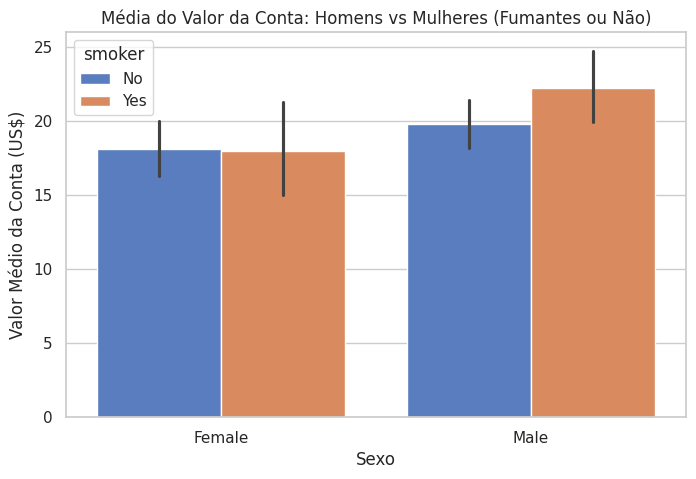

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="sex", y="total_bill", hue="smoker", palette="muted")
plt.title("Média do Valor da Conta: Homens vs Mulheres (Fumantes ou Não)")
plt.xlabel("Sexo")
plt.ylabel("Valor Médio da Conta (US$)")
plt.show()